# ST2195 Programming for Data Science Coursework Part 2

In [1]:
import numpy as np
import pandas as pd
import math as math
import matplotlib.pyplot as plt
import matplotlib.colors as mclrs
import random
import seaborn as sns
import sqlite3
from sklearn.linear_model import LogisticRegression 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split 
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn import metrics
conn = sqlite3.connect("flight1.db")
c = conn.cursor()

In [2]:
import os
os.chdir("C:/Users/fwant/FREDDY/SINGAPORE FREDDY/COURSES/YEAR 2/PROGRAMMING FOR DATA SCIENCE/ST2195_Coursework/Part 2/flights_data")
os.getcwd()

'C:\\Users\\fwant\\FREDDY\\SINGAPORE FREDDY\\COURSES\\YEAR 2\\PROGRAMMING FOR DATA SCIENCE\\ST2195_Coursework\\Part 2\\flights_data'

In [3]:
pd.set_option('display.max_columns', None) # just to view all columns
pd.set_option('display.width', 1000) # to be able to view all the columns
pd.set_option('display.max_rows', None)

In [5]:
y = range(2001,2006,1)
chunk_size = 10000
for i in y:
    dash = pd.read_csv(str("C:/Users/fwant/FREDDY/SINGAPORE FREDDY/COURSES/YEAR 2/PROGRAMMING FOR DATA SCIENCE/ST2195_Coursework/Part 2/flights_data/" + str(i) + ".csv.bz2"), low_memory = False, encoding = "latin1")
    if i == 2001:
        dash.to_sql("data", conn, if_exists = "replace", chunksize = chunk_size)
    else:
        dash.to_sql("data", conn, if_exists = "append", chunksize = chunk_size)

plane_data = pd.read_csv("C:/Users/fwant/FREDDY/SINGAPORE FREDDY/COURSES/YEAR 2/PROGRAMMING FOR DATA SCIENCE/ST2195_Coursework/Part 2/flights_data/plane-data.csv")

del dash

### Remove cancelled or diverted flights

In [6]:
chunks = [] # Storage for each chunk that's loaded
chunk_size = 10000
for chunk in pd.read_sql_query(
    '''
    SELECT Year, DayOfWeek, CRSDepTime, TailNum, DepDelay, ArrDelay 
    FROM data
    WHERE Cancelled = 0 AND Diverted = 0
    ''', conn, chunksize = chunk_size):
    chunks.append(chunk) 

flight = pd.concat(chunks, ignore_index = True) # Combine each chunk into a single table
del chunk, chunks, chunk_size
flight = pd.DataFrame(flight) # Convert data into DataFrame

### Change DayOfWeek into each of their corresponding day names

In [7]:
days = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

flight['DayOfWeek'] = flight['DayOfWeek'].map(days) # Convert numeric day values to corresponding day names

flight['DayOfWeek'] = pd.Categorical(flight['DayOfWeek'], 
                                     categories=["Monday", "Tuesday", "Wednesday", "Thursday", 
                                                 "Friday", "Saturday", "Sunday"], 
                                     ordered=True) # Convert DayOfWeek to a categorical type with proper ordering

flight['TotalDelay'] = flight['DepDelay'] + flight['ArrDelay'] # TotalDelay column

## 2(a) Best Times and Days of the Week to Minimise Flight Delays

In [8]:
flight["TotalDelay"] = flight["DepDelay"] + flight["ArrDelay"]
print(flight.columns)  # Check available columns in flight

if "TailNum" in flight.columns:
    flight.rename(columns={"TailNum": "tailnum"}, inplace=True)

flights = flight[["Year", "DayOfWeek", "CRSDepTime", "DepDelay", "ArrDelay", "TotalDelay", "tailnum"]].copy() # Select relevant columns and reorder it

def categorize_departure_time(time):
    if 0 <= time <= 600:
        return "Dawn"
    elif 601 <= time <= 1200:
        return "Morning"
    elif 1201 <= time <= 1800:
        return "Evening"
    elif 1801 <= time <= 2400:
        return "Night"
    return "Unknown" #mapping for categorized_departure_time

flights["CRSDepTime"] = flights["CRSDepTime"].apply(categorize_departure_time) # Apply the categorized time into the dataset

flights["CRSDepTime"] = pd.Categorical(flights["CRSDepTime"], 
                                       categories=["Dawn", "Morning", "Evening", "Night"], 
                                       ordered=True) # Order the categorized time of day

flights.rename(columns={"CRSDepTime": "SDepPartOfDay", "DayOfWeek": "Day"}, inplace=True) # Rename columns

Index(['Year', 'DayOfWeek', 'CRSDepTime', 'TailNum', 'DepDelay', 'ArrDelay', 'TotalDelay'], dtype='object')


### Group values based on Year, Day, and SDepPartOfDay

In [ ]:
delay_summary = flights.groupby(["Year", "Day", "SDepPartOfDay"], observed=False).sum().reset_index()

flight_counts = flights.groupby(["Year", "Day", "SDepPartOfDay"], observed=False).size().reset_index(name="CountOfFlights") # Convert the grouped delay_summary into a dataframe

### Average delay for each group

In [ ]:
delay_summary = pd.merge(delay_summary, flight_counts, on=["Year", "Day", "SDepPartOfDay"], how="left") # Merge flight counts into delay_summary using a common index

delay_summary["AverageDelay"] = np.round(delay_summary["TotalDelay"] / delay_summary["CountOfFlights"], 2) # Round to 2 decimal points

delay_summary = delay_summary[["Year", "Day", "SDepPartOfDay", "CountOfFlights", "TotalDelay", "AverageDelay"]] # Reorder the columns

In [ ]:
delay_summary.head() # View result

## Visualisation

### Yearly Heatmap which Shows the Average Delay by Day and Time of Day

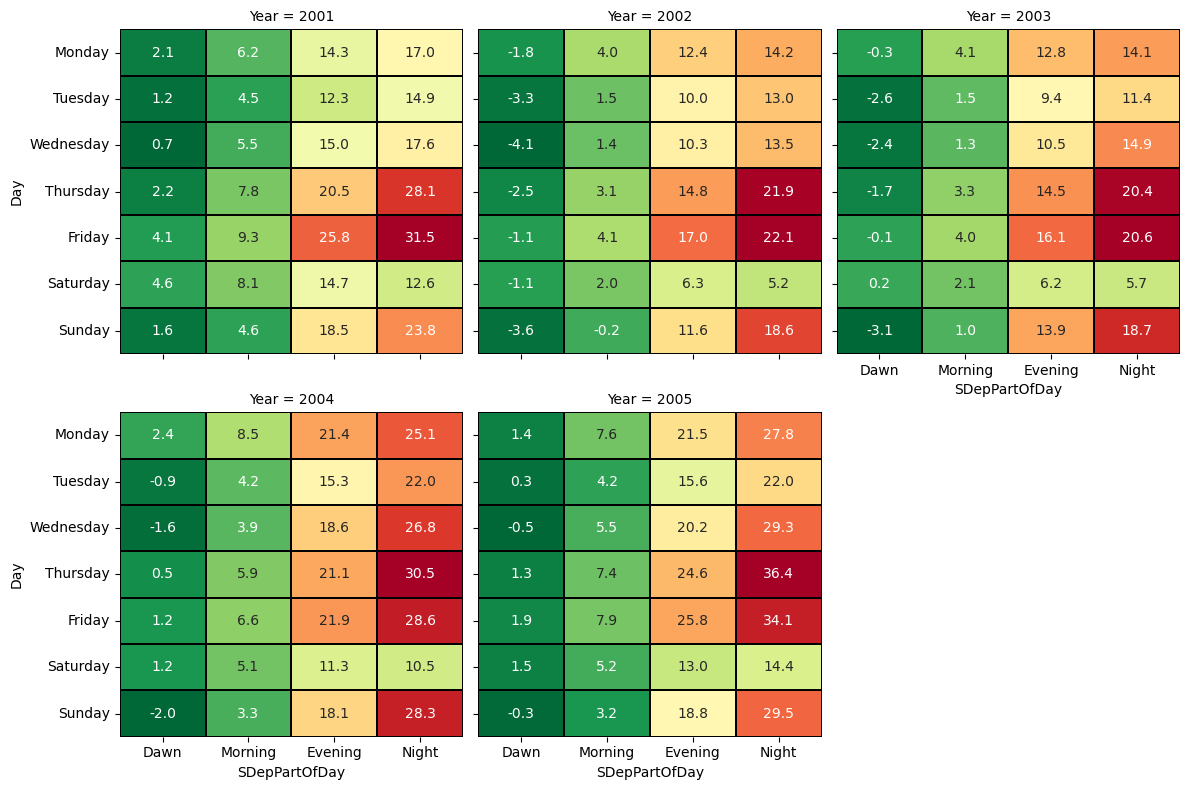

In [241]:
ds = delay_summary.reset_index() # Reset index to convert grouped data into a regular DataFrame

color_palette = sns.color_palette("RdYlGn_r", as_cmap=True) # Green --> Yellow --> Red

facet_grid = sns.FacetGrid(ds, col="Year", col_wrap=3, height=4) # Facet_grid for yearly heatmaps

def create_heatmap(data, **kwargs):
    heatmap_data = data.pivot(index="Day", columns="SDepPartOfDay", values="AverageDelay")
    sns.heatmap(heatmap_data, cmap=color_palette, annot=True, fmt=".1f",
                linewidths=0.1, linecolor="black", cbar=False, **kwargs) # Function to generate heatmaps for each year

facet_grid.map_dataframe(create_heatmap) # Apply the heatmap function to each facet

plt.show() # Display the heatmap

facet_grid.fig.savefig("heatmap_delay.jpeg", dpi=300, format="jpeg", bbox_inches="tight") # Save the faceted heatmap as a JPEG file

## 2(b) Do Older Planes Suffer More Delays on a Year-to-Year Basis

### Identify, Remove, and Fix Tailnums with Incomplete Information

In [117]:
plane_data.isna().sum() # Number of rows with NA values

tailnum            0
type             549
manufacturer     549
issue_date       550
model            549
status           549
aircraft_type    549
engine_type      552
year             694
dtype: int64

In [119]:
planes =  plane_data.dropna(subset = ['type']) # Removes all rows with no values in their 'type' column
planes[planes['status'] != 'Valid'] # 1 Non valid plane
planes = planes[planes['status'] == 'Valid']

In [121]:
planes.isna().sum()

tailnum            0
type               0
manufacturer       0
issue_date         0
model              0
status             0
aircraft_type      0
engine_type        3
year             145
dtype: int64

### Convert 'year' column to numeric and remove invalid years

In [125]:
planes['year'] = pd.to_numeric(planes['year'], errors = 'coerce')
planes = planes[(planes['year'].notna()) & (planes['year'] > 1900)]

In [149]:
flights.rename(columns = {'TailNum': 'tailnum'}, inplace=True) # Rename 'TailNum' to 'tailnum' in flights to match the planes dataset

In [165]:
print(flight.columns)  # Check available columns

Index(['Year', 'DayOfWeek', 'CRSDepTime', 'tailnum', 'DepDelay', 'ArrDelay', 'TotalDelay'], dtype='object')


### Merge flights with planes data on 'tailnum'

In [169]:
flights_planes = flights.merge(planes, on = 'tailnum', how = 'inner')

### Calculate aircraft age and filter out all invalid ages

In [205]:
flights_planes['Year'] = pd.to_numeric(flights_planes['Year'], errors='coerce') # Convert 'Year' to numeric
flights_planes['year'] = pd.to_numeric(flights_planes['year'], errors='coerce') # Convert 'year' to numeric

flights_planes['AircraftAge'] = flights_planes['Year'] - flights_planes['year']
flights_planes = flights_planes[flights_planes['AircraftAge'] >= 0]

### Compute average delay by aircraft age

In [201]:
print(flights_planes.columns) # Check flights_planes columns to make sure all relevant columns are available

Index(['Year', 'Day', 'SDepPartOfDay', 'DepDelay', 'ArrDelay', 'TotalDelay', 'tailnum', 'type', 'manufacturer', 'issue_date', 'model', 'status', 'aircraft_type', 'engine_type', 'year'], dtype='object')


In [193]:
print(flights.columns) # Check flights columns to make sure all relevant columns are available

Index(['Year', 'Day', 'SDepPartOfDay', 'DepDelay', 'ArrDelay', 'TotalDelay', 'tailnum'], dtype='object')


In [197]:
flights_planes = flights.merge(planes, on = 'tailnum', how = 'inner') # Merge flights and planes on 'tailnum'

In [203]:
print(flights_planes[['Year', 'year']].head()) # Make sure 'Year' and 'year' exist in flights_planes

   Year    year
0  2001  1987.0
1  2001  1987.0
2  2001  1987.0
3  2001  1987.0
4  2001  1987.0


In [207]:
print(flights_planes[['AircraftAge']].head()) # Make sure 'AircraftAge' exists in flights_planes

   AircraftAge
0         14.0
1         14.0
2         14.0
3         14.0
4         14.0


In [209]:
delay_by_age = flights_planes.groupby('AircraftAge').agg(
    AverageDepDelay=('DepDelay', 'mean'),
    AverageArrDelay=('ArrDelay', 'mean')
).reset_index()

### Visualisation (Year Combined)

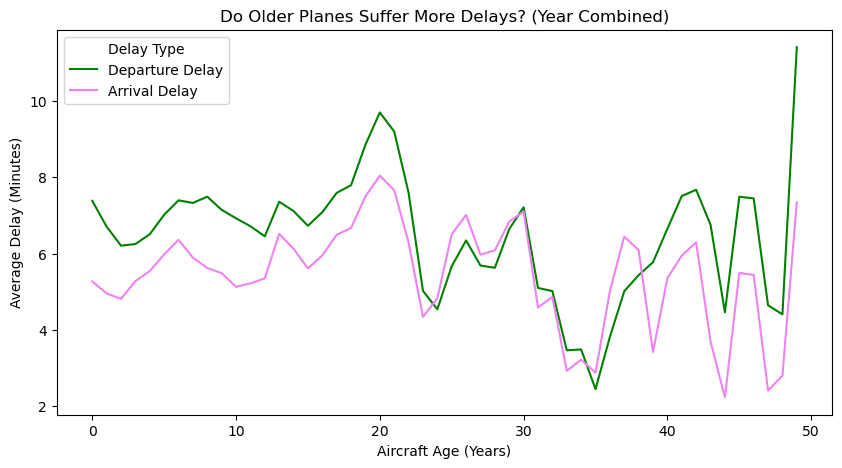

In [245]:
plt.figure(figsize=(10, 5))
sns.lineplot(x='AircraftAge', y='AverageDepDelay', data=delay_by_age, label='Departure Delay', color='green')
sns.lineplot(x='AircraftAge', y='AverageArrDelay', data=delay_by_age, label='Arrival Delay', color='violet')
plt.title("Do Older Planes Suffer More Delays? (Year Combined)")
plt.xlabel("Aircraft Age (Years)")
plt.ylabel("Average Delay (Minutes)")
plt.legend(title="Delay Type")
plt.draw() # For fully rendered JPEG file
plt.savefig("line_plot_delays.jpeg", dpi = 300, format = "jpeg", bbox_inches = "tight")  # Export the line plot as JPEG file
plt.show()

### Visualisation (Per Year)

### Compute average delay by aircraft age per year

In [229]:
delay_by_age_year = flights_planes.groupby(['Year', 'AircraftAge']).agg(
    AverageDepDelay=('DepDelay', 'mean'),
    AverageArrDelay=('ArrDelay', 'mean')
).reset_index()

### Convert 'Year' to categorical for better visualisation

In [237]:
delay_by_age_year['Year'] = delay_by_age_year['Year'].astype(str)

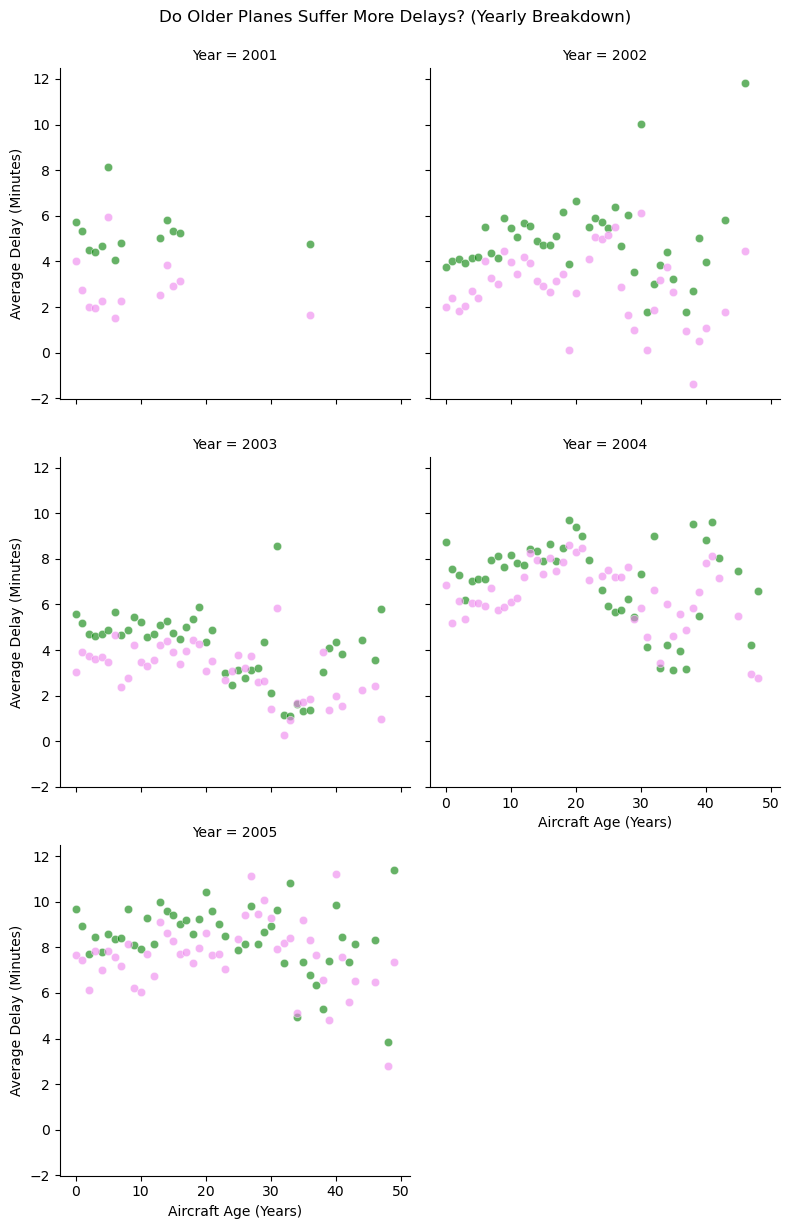

In [239]:
facet_grid = sns.FacetGrid(delay_by_age_year, col='Year', col_wrap=2, height=4)
facet_grid.map_dataframe(sns.scatterplot, x='AircraftAge', y='AverageDepDelay', color='green', alpha=0.6, label='Departure Delay')
facet_grid.map_dataframe(sns.scatterplot, x='AircraftAge', y='AverageArrDelay', color='violet', alpha=0.6, label='Arrival Delay')
facet_grid.set_axis_labels("Aircraft Age (Years)", "Average Delay (Minutes)")
facet_grid.fig.suptitle("Do Older Planes Suffer More Delays? (Yearly Breakdown)", y=1.02)
facet_grid.fig.savefig("scatter_plot_delays.jpeg", dpi=300, format="jpeg", bbox_inches="tight")  # Save the scatter plot
plt.draw()
plt.savefig("scatter_plot_delays.jpeg", dpi = 300, format = "jpeg", bbox_inches = "tight")  # Export the line plot as JPEG file
plt.show()

## 2(c) Logistic Regression Model for the Probability of Diverted US Flights using Available Attributes

### As the question asks us to find out the probability for Diverted US flights, we need to undo the filter on removing diverted flights

In [41]:
chunks = [] # Storage for each chunk that's loaded
chunk_size = 10000
for chunk in pd.read_sql_query(
    '''
    SELECT DayOfWeek, CRSDepTime, DepDelay, CRSElapsedTime, CarrierDelay, WeatherDelay, LateAircraftDelay, UniqueCarrier, Diverted  
    FROM data
    WHERE Cancelled = 0 
    ''', conn, chunksize = chunk_size):
    chunks.append(chunk) # Remove Diverted = 0
flight = pd.concat(chunks, ignore_index = True) # Combine each chunk into a single table
del chunk, chunks, chunk_size
flight = pd.DataFrame(flight) # Convert data into DataFrame

C:\Users\fwant\AppData\Local\Temp\ipykernel_4744\572428228.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  flight = pd.concat(chunks, ignore_index = True) # Combine each chunk into a single table


### Change DayOfWeek into each of their corresponding day names

In [43]:
days = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

flight['DayOfWeek'] = flight['DayOfWeek'].map(days) # Convert numeric day values to corresponding day names

flight['DayOfWeek'] = pd.Categorical(flight['DayOfWeek'], 
                                     categories=["Monday", "Tuesday", "Wednesday", "Thursday", 
                                                 "Friday", "Saturday", "Sunday"], 
                                     ordered=True) # Convert DayOfWeek to a categorical type with proper ordering

### Construct a categorized time for a day

In [ ]:
print(flight.columns)  # Check available columns in flight

In [49]:
def categorize_departure_time(time):
    if 0 <= time <= 600:
        return "Dawn"
    elif 601 <= time <= 1200:
        return "Morning"
    elif 1201 <= time <= 1800:
        return "Evening"
    elif 1801 <= time <= 2400:
        return "Night"
    return "Unknown" #mapping for categorized_departure_time

### Rename 'flight' Dataframe to 'flightdata' for Better Viewing on Columns

In [53]:
flightdata = flight[["DayOfWeek", "CRSDepTime", "DepDelay", "CRSElapsedTime", "CarrierDelay", "WeatherDelay", "LateAircraftDelay", "UniqueCarrier", "Diverted"]].copy() # Select relevant columns and reorder it

In [55]:
flightdata["CRSDepTime"] = flightdata["CRSDepTime"].apply(categorize_departure_time) # Apply the categorized time into the dataset

flightdata["CRSDepTime"] = pd.Categorical(flightdata["CRSDepTime"], 
                                       categories=["Dawn", "Morning", "Evening", "Night"], 
                                       ordered=True) # Order the categorized time of day

flightdata.rename(columns={"CRSDepTime": "SDepPartOfDay", "DayOfWeek": "days"}, inplace=True) # Rename columns

### Show Only US Flight Datasets

In [59]:
us_flights = flightdata[flightdata['UniqueCarrier'].isin(['US'])] # UniqueCarrier brings out the plane's country ownership

### Identifying Predictors

In [77]:
diverted_pred = us_flights[['days', 'SDepPartOfDay', 'CRSElapsedTime', 'DepDelay', 
                            'CarrierDelay', 'WeatherDelay', 'LateAircraftDelay', 
                            'UniqueCarrier', 'Diverted']]
print(diverted_pred)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [69]:
diverted_pred.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2400085 entries, 0 to 30829157
Data columns (total 9 columns):
 #   Column             Dtype   
---  ------             -----   
 0   days               category
 1   SDepPartOfDay      category
 2   CRSElapsedTime     float64 
 3   DepDelay           float64 
 4   CarrierDelay       float64 
 5   WeatherDelay       float64 
 6   LateAircraftDelay  float64 
 7   UniqueCarrier      object  
 8   Diverted           int64   
dtypes: category(2), float64(5), int64(1), object(1)
memory usage: 151.1+ MB


In [91]:
diverted_pred = diverted_pred.drop(columns=['UniqueCarrier'])
categorical = diverted_pred[['days', 'SDepPartOfDay']]
days = pd.get_dummies(categorical['days'], drop_first = True)
SDepPartOfDay = pd.get_dummies(categorical['SDepPartOfDay'], drop_first = True)
categorical.drop(['days', 'SDepPartOfDay'], axis = 1, inplace = True)
categorical = pd.concat([days, SDepPartOfDay], axis = 1)
categorical.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2400085 entries, 0 to 30829157
Data columns (total 9 columns):
 #   Column     Dtype
---  ------     -----
 0   Tuesday    bool 
 1   Wednesday  bool 
 2   Thursday   bool 
 3   Friday     bool 
 4   Saturday   bool 
 5   Sunday     bool 
 6   Morning    bool 
 7   Evening    bool 
 8   Night      bool 
dtypes: bool(9)
memory usage: 38.9 MB


C:\Users\fwant\AppData\Local\Temp\ipykernel_4744\2472931714.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  categorical.drop(['days', 'SDepPartOfDay'], axis = 1, inplace = True)


In [95]:
numerical = diverted_pred[['CRSElapsedTime', 'DepDelay', 'CarrierDelay', 'WeatherDelay', 'LateAircraftDelay',]].copy()

features = pd.concat([categorical, numerical], axis = 1)
features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2400085 entries, 0 to 30829157
Data columns (total 14 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Tuesday            bool   
 1   Wednesday          bool   
 2   Thursday           bool   
 3   Friday             bool   
 4   Saturday           bool   
 5   Sunday             bool   
 6   Morning            bool   
 7   Evening            bool   
 8   Night              bool   
 9   CRSElapsedTime     float64
 10  DepDelay           float64
 11  CarrierDelay       float64
 12  WeatherDelay       float64
 13  LateAircraftDelay  float64
dtypes: bool(9), float64(5)
memory usage: 130.5 MB


### These features will serve for creating the logistic regression model

### Preparing the Data

In [101]:
X = features.copy()
Y = diverted_pred['Diverted'].copy()

## Logistic Regression Model
#### The use of this model is to predict each of the US flights on whether it would be diverted or not. Hence, the possible outcome made out of this model is either "Diverted" or "Undiverted".

In [133]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 1)
logreg = pd.concat([X_train, Y_train], axis=1)

# Fill all NA Values from X_test to Median Values in X_train
X_test.loc[X_test['CRSElapsedTime'].isna(), 'CRSElapsedTime'] = X_train['CRSElapsedTime'].median(skipna=True)
X_test.loc[X_test['DepDelay'].isna(), 'DepDelay'] = X_train['DepDelay'].median(skipna=True)
X_test.loc[X_test['CarrierDelay'].isna(), 'CarrierDelay'] = X_train['CarrierDelay'].median(skipna=True)
X_test.loc[X_test['WeatherDelay'].isna(), 'WeatherDelay'] = X_train['WeatherDelay'].median(skipna=True)
X_test.loc[X_test['LateAircraftDelay'].isna(), 'LateAircraftDelay'] = X_train['LateAircraftDelay'].median(skipna=True)

## Confusion Matrix
#### Used for testing whether the model is reliable or not for predicting US diverted flights

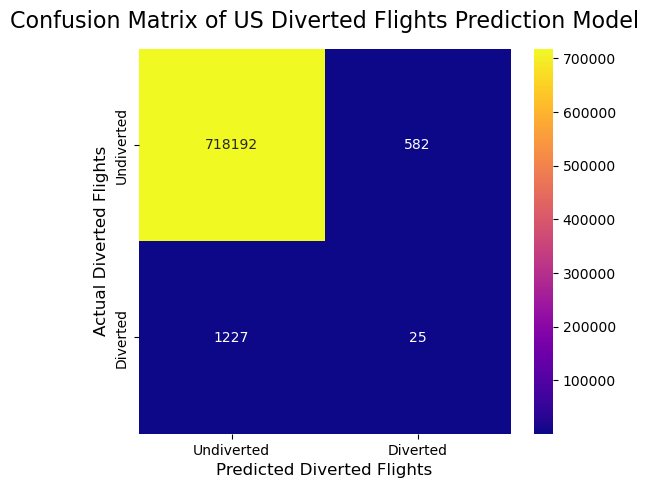

In [159]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = "median") # Replace NaN values with median
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

logreg = LogisticRegression() # Ensure 'logreg' is a logistic regression
logreg.fit(X_train, Y_train)
Y_pred = logreg.predict(X_test)
cnf_matrix = metrics.confusion_matrix(Y_test, Y_pred) # Confusion Matrix
class_names = ["Undiverted", "Diverted"] # Class labels
fig, ax = plt.subplots(figsize = (6, 5))  # Adjust figure size
sns.heatmap(cnf_matrix, annot = True, fmt = 'd', cmap = "plasma", xticklabels = class_names, yticklabels = class_names) # Heatmap with its labels
ax.set_title("Confusion Matrix of US Diverted Flights Prediction Model", fontsize = 16, pad = 15) 
ax.set_xlabel("Predicted Diverted Flights", fontsize = 12)
ax.set_ylabel("Actual Diverted Flights", fontsize = 12)

plt.show() # Showing the heatmap plot

In [161]:
print("Accuracy:",metrics.accuracy_score(Y_test, Y_pred))
print("Precision:",metrics.precision_score(Y_test, Y_pred))
print("Recall:",metrics.recall_score(Y_test, Y_pred))

Accuracy: 0.9974875907258904
Precision: 0.04118616144975288
Recall: 0.019968051118210862


#### The confusion matrix shows that the model is highly accurate (99.75%). However, almost all flights are "undiverted", leading to an imbalance datasets. Therefore, it cannot be concluded that the model is sufficient for future use.
#### Low precision shown by the confusion matrix explains that only 4.12% of the "predicted diverted flights" made by the model were correct. This means that the model misses each prediction most of the time, which led to a false positive outcome (positive = diverted flight).
#### Recall explains about how often the model correctly predicts the "actual diverted flights". This means that the model misses 98% of the time for correctly predicting the "actual diverted flights".

## ROC Curve
#### The ROC Curve serves the same purpose as the confusion matrix, where it is used to further test the accuracy of this model.

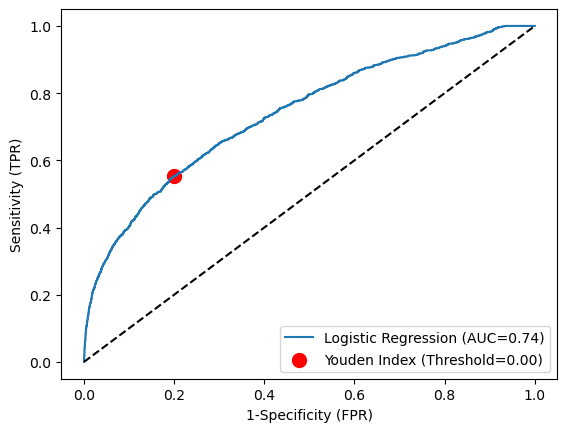

In [191]:
from sklearn.metrics import RocCurveDisplay

fpr, tpr, thresholds = metrics.roc_curve(Y_test, y_pred_proba)
auc = metrics.roc_auc_score(Y_test, y_pred_proba)

# Optimal Threshold
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]

optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]

plt.figure()
plt.step(fpr, tpr, where = "post", label = f"Logistic Regression (AUC={auc:.2f})")
plt.plot([0, 1], [0, 1], color = "black", linestyle = "--")
plt.scatter(optimal_fpr, optimal_tpr, color="red", s=100, label= f"Youden Index (Threshold={optimal_threshold:.2f})") # Youden Index Point
plt.xlabel("1-Specificity (FPR)")
plt.ylabel("Sensitivity (TPR)")
plt.legend(loc = "lower right")
plt.show()


#### AUC from the ROC curve shows the score of the logistic regression model. Here AUC = 0.74 means that the model is considered as an acceptable model. The Youden Index is a metric used in ROC curve analysis to determine the optimal threshold. 
#### The red dotted point which corresponds to the highest Youden Index represents the ideal balance between true positive and false positive rates, making it the best threshold for accurately identifying diverted US flights while minimizing incorrect predictions.